In [3]:
%pip install opencv-python  --no-deps matplotlib

Note: you may need to restart the kernel to use updated packages.


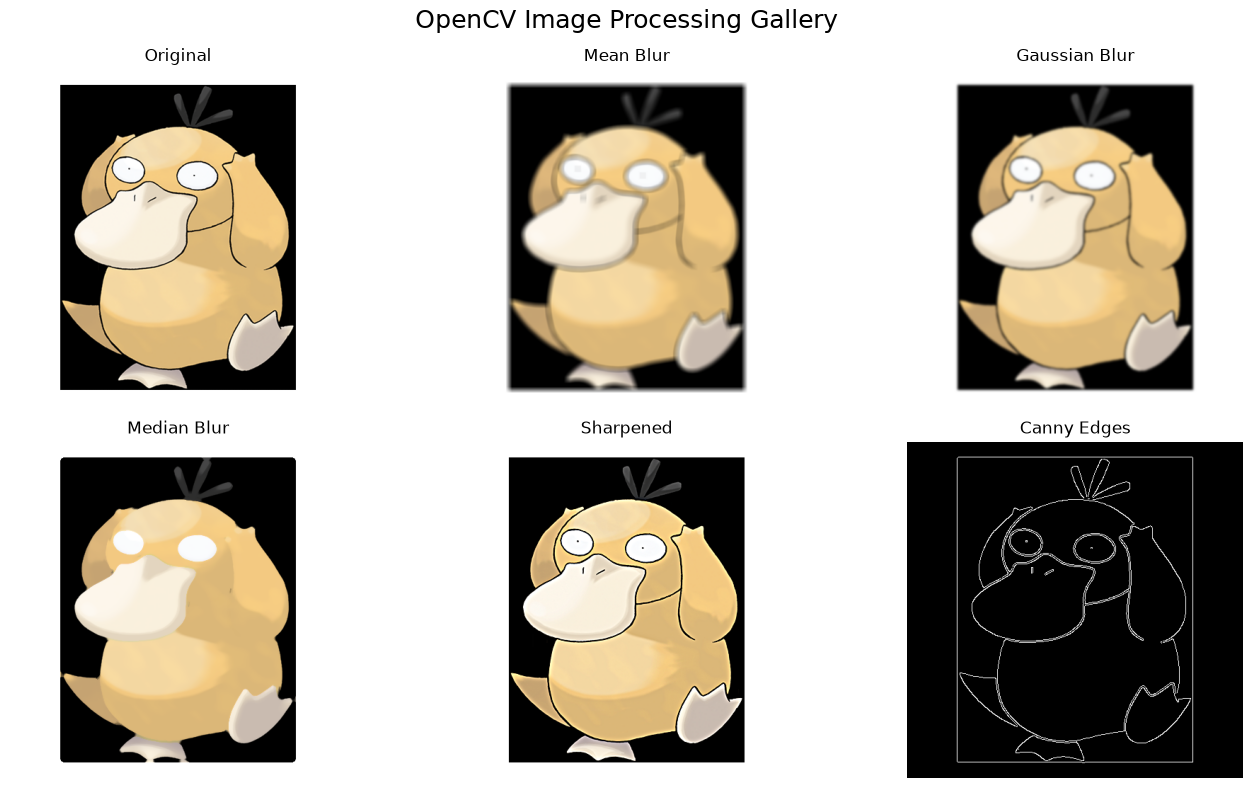

In [2]:
import cv2
import matplotlib.pyplot as plt

# Load image and convert OpenCV's BGR format to RGB
image = cv2.imread("054.png")
if image is None:
    raise FileNotFoundError("Could not find image.jpg")
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Apply several OpenCV effects
mean_blur = cv2.blur(rgb, (9, 9))
gaussian_blur = cv2.GaussianBlur(rgb, (9, 9), 0)
median_blur = cv2.medianBlur(rgb, 9)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 80, 160)

# Create a sharpened version
blurred = cv2.GaussianBlur(rgb, (0, 0), 3)

sharpened = cv2.addWeighted(
    rgb, 1.7,
    blurred, -0.7,
    0
)

# Display everything in a gallery
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

images = [
    (rgb, "Original", None),
    (mean_blur, "Mean Blur", None),
    (gaussian_blur, "Gaussian Blur", None),
    (median_blur, "Median Blur", None),
    (sharpened, "Sharpened", None),
    (edges, "Canny Edges", "gray"),
]

for ax, (img, title, cmap) in zip(axes.flat, images):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("OpenCV Image Processing Gallery", fontsize=18)
plt.tight_layout()
plt.show()